# Pizza Plot for Cambridge United Analysis
### James Brophy - Cambridge United - EFL League Two 2025-26

In [1]:
# Import necessary packages
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

from mplsoccer import PyPizza, add_image, FontManager
from scipy import stats
from PIL import Image
from urllib.request import urlopen # only required if using an image from a URL

In [2]:
# Define variables to be used in code

source_data_name = "Wyscout_League_Export 2026-04-14.csv" # File name for data

selected_positions = ["RW", "LW", "AMF", "RAMF", "LAMF", "RWF", "LWF"] # Position(s) of interest

selected_leagues = ['England League Two 2025-26'] # League(s) of interest

selected_player = 'J. Brophy' # Player to visualise

selected_metrics = [# Passing
                    'Progressive passes per 90',
                    'Accurate progressive passes, %',
                    'Passes per 90',
                    'Accurate passes, %',

                    # Creativity
                    'Key passes per 90',
                    'xA per 90',
                    'Deep completions per 90',

                    # Crossing
                    'Accurate crosses, %',
                    'Crosses per 90',

                    # Dribbling
                    'Successful dribbles, %',
                    'Dribbles per 90',
                    'Accelerations per 90',

                    # Shooting
                    'Non-penalty goals per 90',
                    'xG per 90',
                    'Shots on target, %',

                    # Defending
                    'Defensive duels won, %',
                    'Successful defensive actions per 90',
                    'Defensive duels per 90'
                    ] # Metric columns for visual. The order here determines the order on the visual

selected_columns = ['Player', 'Team'] # Additional columns required, e.g. name, team, etc.

minutes_filter = 450 # value used to filter for minutes played



In [3]:
# Load the data
df_source = pd.read_csv(source_data_name)

# Create lists to help understand what is present in the data
list_all_columns = list(df_source.columns) # columns in dataset
list_all_leagues = list(df_source["League"].unique())
list_all_positions = list(df_source["Main Position"].unique())

# Print lists to enable variable definition
print(f"Columns Available: \n {list_all_columns}")
print(f"\n Leagues Included: \n {list_all_leagues}")
print(f"\n Positions Included: \n {list_all_positions}")

Columns Available: 
 ['Player', 'Team', 'Team within selected timeframe', 'Position', 'Age', 'Market value', 'Contract expires', 'Matches played', 'Minutes played', 'Goals', 'xG', 'Assists', 'xA', 'Duels per 90', 'Duels won, %', 'Birth country', 'Passport country', 'Foot', 'Height', 'Weight', 'On loan', 'Successful defensive actions per 90', 'Defensive duels per 90', 'Defensive duels won, %', 'Aerial duels per 90', 'Aerial duels won, %', 'Sliding tackles per 90', 'PAdj Sliding tackles', 'Shots blocked per 90', 'Interceptions per 90', 'PAdj Interceptions', 'Fouls per 90', 'Yellow cards', 'Yellow cards per 90', 'Red cards', 'Red cards per 90', 'Successful attacking actions per 90', 'Goals per 90', 'Non-penalty goals', 'Non-penalty goals per 90', 'xG per 90', 'Head goals', 'Head goals per 90', 'Shots', 'Shots per 90', 'Shots on target, %', 'Goal conversion, %', 'Assists per 90', 'Crosses per 90', 'Accurate crosses, %', 'Crosses from left flank per 90', 'Accurate crosses from left flank, %

In [4]:
# Filter the data
df_filtered = df_source # create a new df that will be filtered
df_filtered = df_filtered[ df_filtered['Main Position'].isin(selected_positions) ] # filter for players who play in the selected position
df_filtered = df_filtered[ df_filtered['League'].isin(selected_leagues) ] #
df_filtered = df_filtered[ df_filtered['Minutes played'] >= minutes_filter ] # filter for players who meet the minutes played threshold

# Create list of players to choose from
list_all_players = list(df_filtered['Player'])
print(f"Players Available: \n {list_all_players}")

Players Available: 
 ['M. Pinnock', 'R. Glover', 'R. Smith', "T. O'Reilly", 'T. Iorpenda', 'C. Agius', 'I. Sinclair', 'J. Brophy', 'K. Lisbie', 'S. Kaikai', 'J. Thomas', 'C. Whitely', 'C. Whitaker', 'J. Payne', 'B. Kamwa', 'C. Vernam', 'S. Whalley', 'D. Markanday', 'B. Dack', 'L. Mandeville', 'D. Burns', 'R. Darcy', 'K. Drummond', 'C. Stead', 'H. Anderson', 'O. Lunt', 'C. Grant', 'M. Holíček', 'B. Knight', 'E. Taylor', 'E. Archer', 'B. Lloyd', 'K. Payne', 'B. Krauhaus', 'L. Thomas', 'A. Dobra', 'J. Earing', 'T. McDermott', 'A. Mayor', 'C. Mahoney', 'A. Scully', 'M. Spellman', 'S. Duke-McKenna', 'D. Duffy', 'T. Hall', 'J. Berry-McNally', 'S. Forde', 'I. Fletcher', 'O. Edwards', 'A. Henderson', 'L. Hannant', 'G. McCleary', 'P. Glatzel', 'B. Thompson', 'J. Stevens', 'K. Whitmore', 'J. Obiora Amaluzor', 'J. Hawkes', 'C. McAleny', 'Z. Obiero', 'B. Bodin', 'G. Holohan', 'T. Brenan', 'M. Clark', 'K. Lolos', 'P. Ehibhatiomhan', 'T. Leigh', 'J. Martin', 'R. Sotiriou', 'K. Dixon', 'H. Adelakun',

In [5]:
# Create the dataset for the analysis by removing unwanted columns

df_dataset = df_filtered # create a new df that will be used for the analysis
df_dataset = df_dataset.filter(selected_columns + selected_metrics, axis=1) # keep only the columns selected earlier

# Create a list of the metrics
list_metrics = list(selected_metrics)
list_metrics


['Progressive passes per 90',
 'Accurate progressive passes, %',
 'Passes per 90',
 'Accurate passes, %',
 'Key passes per 90',
 'xA per 90',
 'Deep completions per 90',
 'Accurate crosses, %',
 'Crosses per 90',
 'Successful dribbles, %',
 'Dribbles per 90',
 'Accelerations per 90',
 'Non-penalty goals per 90',
 'xG per 90',
 'Shots on target, %',
 'Defensive duels won, %',
 'Successful defensive actions per 90',
 'Defensive duels per 90']

In [6]:
# Calculate selected player percentiles

# Filter for the selected player and reset the index
df_player_pct = df_dataset.loc[ df_dataset['Player'] == selected_player ].reset_index()
df_player_pct.loc[0]


index                                             19432
Player                                        J. Brophy
Team                                   Cambridge United
Progressive passes per 90                          6.03
Accurate progressive passes, %                    76.38
Passes per 90                                     32.04
Accurate passes, %                                73.82
Key passes per 90                                  0.76
xA per 90                                          0.25
Deep completions per 90                            1.24
Accurate crosses, %                               40.23
Crosses per 90                                     2.63
Successful dribbles, %                            45.45
Dribbles per 90                                     3.0
Accelerations per 90                               0.24
Non-penalty goals per 90                           0.09
xG per 90                                          0.08
Shots on target, %                              

In [7]:
# Optional export of percentile data to csv
# pd.DataFrame([player_percentiles], columns=list_metrics).to_csv('Largie Ramazani Percentiles La Liga.csv', index=False)
# player_percentiles and list_metrics are both lists - i.e. 1 column, multiple rows
# wrapping player_percentiles in square brackets essentially transposes them
# columns can take the form of a list and therefore does not need transposing

In [8]:
# Get the selected player's data
list_player_values = list(df_player_pct.loc[0])

# Remove first 3 columns (index, player, team)
list_player_values = list_player_values[3:]

# Player percentiles
player_percentiles = [] # create an empty list
for x in range(len(list_metrics)):
    player_percentiles.append( math.floor( stats.percentileofscore( df_dataset[list_metrics[x]],
                                                                    list_player_values[x]
                                                                    ) ) )

In [9]:
list_player_values[0]

np.float64(6.03)

In [10]:
list_metrics[0]

'Progressive passes per 90'

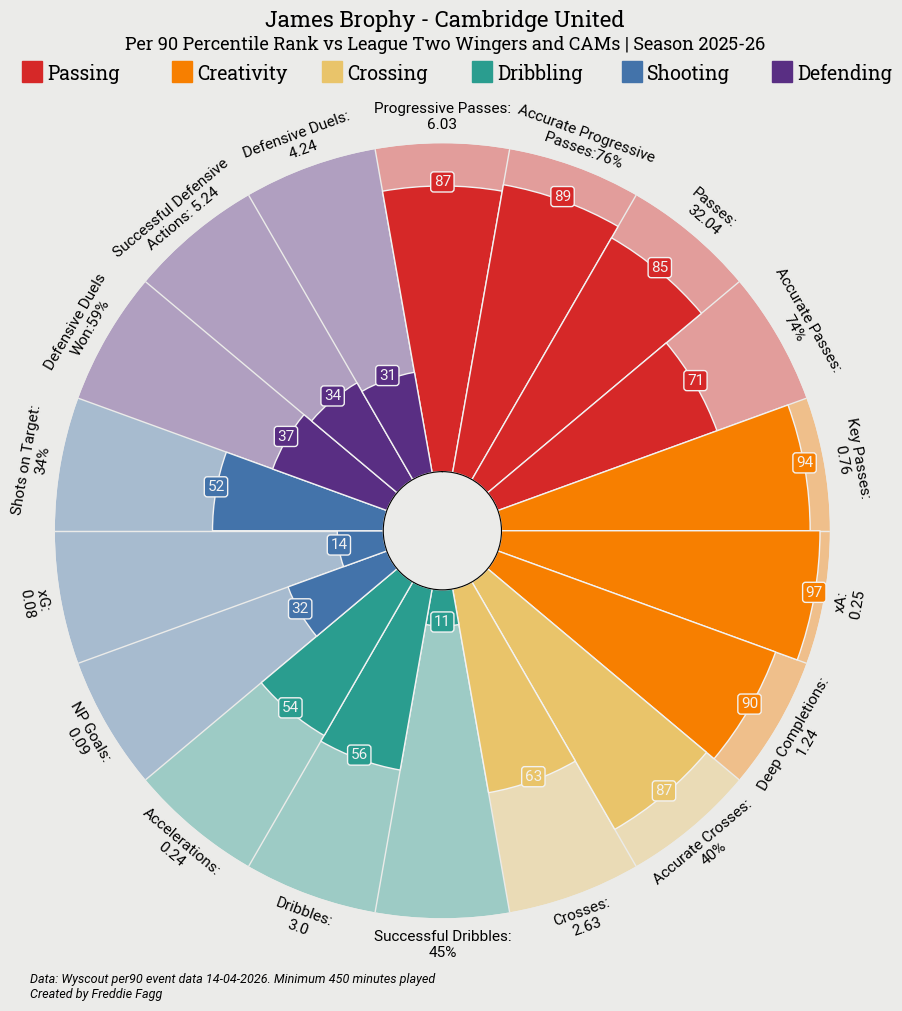

In [11]:
# Creating the Visual

# Load fonts
# MPLsoccer FontManager guide: https://mplsoccer.readthedocs.io/en/latest/mplsoccer.utils.html#mplsoccer.utils.FontManager
font_normal = FontManager('https://raw.githubusercontent.com/googlefonts/roboto/main/'
                          'src/hinted/Roboto-Regular.ttf')
font_italic = FontManager('https://raw.githubusercontent.com/googlefonts/roboto/main/'
                          'src/hinted/Roboto-Italic.ttf')
font_bold = FontManager('https://raw.githubusercontent.com/google/fonts/main/apache/robotoslab/'
                        'RobotoSlab[wght].ttf')

# Colour for the slices and text
colour_1 = "#D62828" 
colour_2 = "#F77F00"
colour_3 = "#E9C46A" # 1st to remove
colour_4 = "#2A9D8F" # 2nd to remove
colour_5 = "#4373AA"
colour_6 = "#592E83"
colour_t = "#f2f2f2" # colour for label boxes and text
slice_colours = [colour_1] * 4 + [colour_2] * 3 + [colour_3] * 2 + [colour_4] * 3 + [colour_5] * 3 + [colour_6] * 3 # number must add up to total number of metrics
text_colours =  [colour_t] * 4 + [colour_t] * 3 + [colour_t] * 2 + [colour_t] * 3 + [colour_t] * 3 + [colour_t] * 3 # numbers must match line above

# Alternative colours (not used)
alt_1 = "#B81F1F"
alt_2 = "#E97431"
alt_3 = "#4E963C"
alt_4 = "#4373AA"

# Text inputs
text_title = "James Brophy - Cambridge United"
text_subtitle = "Per 90 Percentile Rank vs League Two Wingers and CAMs | Season 2025-26"

text_legend_1 = "Passing"
text_legend_2 = "Creativity"
text_legend_3 = "Crossing"
text_legend_4 = "Dribbling"
text_legend_5 = "Shooting"
text_legend_6 = "Defending"

text_credit_1 = f"Data: Wyscout per90 event data 14-04-2026. Minimum {minutes_filter} minutes played"
text_credit_2 = "Created by Freddie Fagg"
text_save_name = "James Brophy - League Two 2025-26.png"
text_metric_labels =  [ # Passing:
                        f'Progressive Passes:\n{list_player_values[0]}', 
                        f'Accurate Progressive\n Passes:{round(list_player_values[1])}%',
                        f'Passes:\n{list_player_values[2]}', 
                        f'Accurate Passes:\n{round(list_player_values[3])}%', 

                        # Creativity:
                        f'Key Passes:\n{list_player_values[4]}', 
                        f'xA:\n{list_player_values[5]}', 
                        f'Deep Completions:\n{list_player_values[6]}', 
                        
                        # Crossing:
                        f'Accurate Crosses:\n{round(list_player_values[7])}%', 
                        f'Crosses:\n{list_player_values[8]}', 
                        
                        # Dribbling:
                        f'Successful Dribbles:\n{round(list_player_values[9])}%', 
                        f'Dribbles:\n{list_player_values[10]}',
                        f'Accelerations:\n{list_player_values[11]}',  
                        
                        # Shooting:
                        f'NP Goals: \n{list_player_values[12]}', 
                        f'xG: \n{list_player_values[13]}',
                        f'Shots on Target: \n{round(list_player_values[14])}%', 
                        
                        # Defending:
                        f'Defensive Duels \nWon:{round(list_player_values[15])}%', 
                        f'Successful Defensive\n Actions: {list_player_values[16]}',
                        f'Defensive Duels: \n{list_player_values[17]}',
                        ]

# Legend positions
box_gapx = 0.15 # horizontal gap between boxes
text_gapx = 0.025 # horizontal gap between each box and corresponding text
text_gapy = 0.0025 # vertical gap between bottom of each box and bottom of corresponding text

box_posx_1 = 0.0925
box_posy_1 = 0.9225
box_posx_2 = box_posx_1 + box_gapx 
box_posy_2 = box_posy_1 # same height as box 1
box_posx_3 = box_posx_2 + box_gapx
box_posy_3 = box_posy_1 # same height as box 1
box_posx_4 = box_posx_3 + box_gapx
box_posy_4 = box_posy_1 # same height as box 1
box_posx_5 = box_posx_4 + box_gapx
box_posy_5 = box_posy_1 # same height as box 1
box_posx_6 = box_posx_5 + box_gapx
box_posy_6 = box_posy_1 # same height as box 1

legend_posx_1 = box_posx_1 + text_gapx
legend_posy_1 = box_posy_1 + text_gapy
legend_posx_2 = legend_posx_1 + box_gapx
legend_posy_2 = legend_posy_1 # same height as text 1
legend_posx_3 = legend_posx_2 + box_gapx
legend_posy_3 = legend_posy_1 # same height as text 1
legend_posx_4 = legend_posx_3 + box_gapx
legend_posy_4 = legend_posy_1 # same height as text 1
legend_posx_5 = legend_posx_4 + box_gapx
legend_posy_5 = legend_posy_1 # same height as text 1
legend_posx_6 = legend_posx_5 + box_gapx
legend_posy_6 = legend_posy_1 # same height as text 1

# instantiate PyPizza class
baker = PyPizza(
    params=text_metric_labels,            # list of parameters, used for labels
    background_color="#EBEBE9",         # background color
    straight_line_color="#EBEBE9",      # color for straight lines
    straight_line_lw=1,                   # linewidth for straight lines
    last_circle_lw=0,                     # linewidth of last circle
    other_circle_lw=0,                    # linewidth for other circles
    inner_circle_size=18                  # size of inner circle
)

# plot pizza
fig, ax = baker.make_pizza(
    player_percentiles,              # list of values
    figsize=(10, 10.5),                # adjust figsize according to your need
    color_blank_space="same",        # use same color to fill blank space
    slice_colors=slice_colours,       # color for individual slices
    value_colors=text_colours,        # color for the value-text
    value_bck_colors=slice_colours,   # color for the blank spaces
    blank_alpha=0.4,                 # alpha for blank-space colors
    kwargs_slices=dict(
        edgecolor="#f2f2f2", zorder=2, linewidth=1
    ),                               # values to be used when plotting slices
    kwargs_params=dict(
        color="#000000", fontsize=11, # font size for metric labels
        fontproperties=font_normal.prop, va="center"
    ),                               # values to be used when adding parameter
    kwargs_values=dict(
        color="#000000", fontsize=11,
        fontproperties=font_normal.prop, zorder=3,
        bbox=dict(
            edgecolor=colour_t, facecolor="cornflowerblue", # colour of label box outline
            boxstyle="round,pad=0.2", lw=1
        )
    )                                # values to be used when adding parameter-values
)

# add title
fig.text(
    0.515, 0.975, 
    text_title, 
    size=16,
    ha="center", 
    fontproperties=font_bold.prop, 
    color="#000000")

# add subtitle
fig.text(
    0.515, 0.953,
    text_subtitle,
    size=13,
    ha="center", 
    fontproperties=font_bold.prop, 
    color="#000000")

# add footnotes
fig.text(
    0.1, 0.05, 
    f"{text_credit_1}\n{text_credit_2}", 
    size=9,
    fontproperties=font_italic.prop, 
    color="#000000",
    ha="left")

# add legend text 1
fig.text(legend_posx_1, legend_posy_1, # x, y coordinates
    text_legend_1, 
    size=14,
    fontproperties=font_bold.prop, 
    color="#000000")

# add legend text 2
fig.text(legend_posx_2, legend_posy_2, # x, y coordinates
    text_legend_2, 
    size=14,
    fontproperties=font_bold.prop, 
    color="#000000")

# add legend text 3
fig.text(legend_posx_3, legend_posy_3, # x, y coordinates 
    text_legend_3, 
    size=14,
    fontproperties=font_bold.prop, 
    color="#000000")

# add legend text 4
fig.text(legend_posx_4, legend_posy_4, # x, y coordinates 
    text_legend_4, 
    size=14,
    fontproperties=font_bold.prop, 
    color="#000000")

# add legend text 5
fig.text(legend_posx_5, legend_posy_5, # x, y coordinates 
    text_legend_5, 
    size=14,
    fontproperties=font_bold.prop, 
    color="#000000")

# add legend text 6
fig.text(legend_posx_6, legend_posy_6, # x, y coordinates 
    text_legend_6, 
    size=14,
    fontproperties=font_bold.prop, 
    color="#000000")

# add legend rectangles
box_width = 0.02 # setting for boxes
box_height = 0.02 # setting for boxes

fig.patches.extend([
# Colour 1
    plt.Rectangle(
        (box_posx_1, box_posy_1), # x, y location
        box_width, box_height, # width, height
        fill=True, 
        color= colour_1,
        transform=fig.transFigure, 
        figure=fig),
# Colour 2
    plt.Rectangle(
        (box_posx_2, box_posy_2), 
        box_width, box_height, 
        fill=True, 
        color=colour_2,
        transform=fig.transFigure, 
        figure=fig),
# Colour 3
    plt.Rectangle(
        (box_posx_3, box_posy_3), 
        box_width, box_height, 
        fill=True, 
        color=colour_3,
        transform=fig.transFigure, 
        figure=fig),
# Colour 4
    plt.Rectangle( 
        (box_posx_4, box_posy_4), 
        box_width, box_height, 
        fill=True, 
        color=colour_4,
        transform=fig.transFigure, 
        figure=fig),
# Colour 5
    plt.Rectangle( 
        (box_posx_5, box_posy_5), 
        box_width, box_height, 
        fill=True, 
        color=colour_5,
        transform=fig.transFigure, 
        figure=fig),
# Colour 6
    plt.Rectangle( 
        (box_posx_6, box_posy_6), 
        box_width, box_height, 
        fill=True, 
        color=colour_6,
        transform=fig.transFigure, 
        figure=fig),
])

# load image and plot it
#fdj_cropped = Image.open("Largie Ramazani PNG.png") # load 250x250 cropped circle
#ax_image = add_image(fdj_cropped, fig, left=0.455, bottom=0.435, width=0.115, height=0.12)   # these values might differ when you are plotting

# Save the visual
fig.savefig(text_save_name, dpi=300, bbox_inches="tight")